In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import time

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face
from datasets import load_dataset

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yash\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
dataset = load_dataset("bdstar/twitter-sentiment-analysis")

df = pd.DataFrame(dataset['train'])
df.head()

README.md: 0.00B [00:00, ?B/s]

C:\Users\Yash\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Yash\.cache\huggingface\hub\datasets--bdstar--twitter-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP 

train.json:   0%|          | 0.00/361M [00:00<?, ?B/s]

validation.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test.json:   0%|          | 0.00/198M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3142209 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/31014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1600000 [00:00<?, ? examples/s]

,ID,text,label
0,1,is upset that he can't update his Facebook by ...,negative
1,2,@Kenichan I dived many times for the ball. Man...,negative
2,3,my whole body feels itchy and like its on fire,negative
3,4,"@nationwideclass no, it's not behaving at all....",negative
4,5,@Kwesidei not the whole crew,negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142209 entries, 0 to 3142208
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   ID      int64 
 1   text    object
 2   label   object
dtypes: int64(1), object(2)
memory usage: 71.9+ MB


In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df.head()

,ID,text,label,clean_text
0,1,is upset that he can't update his Facebook by ...,negative,upset cant update facebook texting might cry r...
1,2,@Kenichan I dived many times for the ball. Man...,negative,dived many time ball managed save rest go bound
2,3,my whole body feels itchy and like its on fire,negative,whole body feel itchy like fire
3,4,"@nationwideclass no, it's not behaving at all....",negative,behaving im mad cant see
4,5,@Kwesidei not the whole crew,negative,whole crew


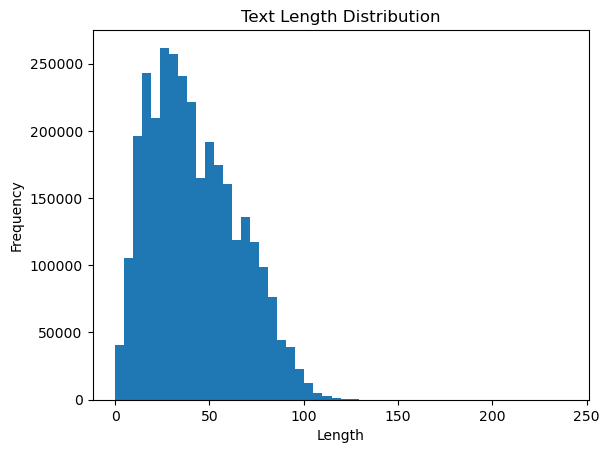

In [9]:
df['text_length'] = df['clean_text'].apply(len)

plt.hist(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [11]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(20)

pd.DataFrame(word_freq, columns=['Word', 'Frequency'])

,Word,Frequency
0,im,228714
1,day,209993
2,good,176006
3,get,170777
4,like,158261
5,go,154919
6,u,137944
7,today,134387
8,love,133542
9,work,132811


In [15]:
df.columns

Index(['ID', 'text', 'label', 'clean_text', 'text_length'], dtype='object')

In [17]:
df = df.rename(columns={'label': 'sentiment'})

In [19]:
df.columns


Index(['ID', 'text', 'sentiment', 'clean_text', 'text_length'], dtype='object')

In [21]:
df[['text', 'sentiment']].sample(5)


,text,sentiment
1324968,@thomcopestake hopefully. Least my party of ch...,positive
3116103,sorry ryan adams song,positive
2882598,is soooooo excited about tomorrow girls aloud,positive
2184252,it s gonna be another wet day,negative
2411002,i know haha thanks for the reminder quot i jus...,positive


In [23]:
raw_words = " ".join(df['text'].str.lower()).split()
Counter(raw_words).most_common(20)

[('i', 1690082),
 ('to', 1123752),
 ('the', 1041511),
 ('a', 756220),
 ('my', 625887),
 ('and', 599835),
 ('you', 527321),
 ('it', 493731),
 ('is', 466948),
 ('for', 429082),
 ('in', 428385),
 ('of', 368478),
 ('on', 329317),
 ('so', 296966),
 ('that', 292193),
 ('me', 287715),
 ('have', 287503),
 ('but', 258069),
 ('just', 250367),
 ('with', 229043)]

In [27]:
X = df['clean_text']
y = df['sentiment']

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.78      0.75      0.76    314516
     neutral       0.70      0.32      0.44      2144
    positive       0.75      0.79      0.77    311782

    accuracy                           0.77    628442
   macro avg       0.75      0.62      0.66    628442
weighted avg       0.77      0.77      0.77    628442



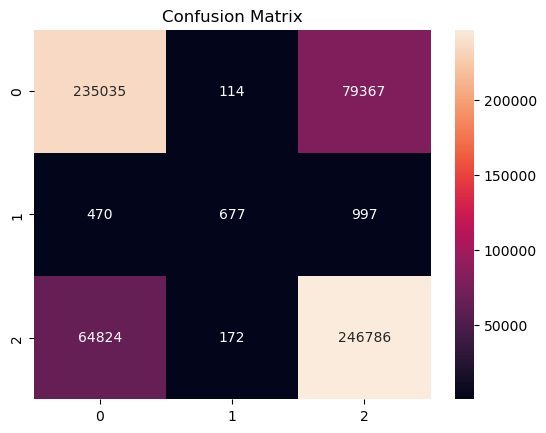

In [35]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [37]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']